# Final Project Notebook

## Client: Maple Bank

Problem (Taken from Client Proposal):

Over the years, Maple Bank has experienced an increase in fraudulent credit card
transactions. This has led to higher financial losses and more customer complaints.
The Maple fraud team and management are currently considering three possible ways
to respond:

    ● Option A: Hire more fraud analysts and increase manual review.
    ● Option B: Detect fraud using simple transaction rules such as transaction amount or location.
    ● Option C: Develop a model that predicts whether a transaction is fraudulent or not based on numerous transaction characteristics.


The Task:

    ● Phase 1:
        ○ Conduct exploratory data analysis to examine and identify characteristics of legitimate and fraudulent transactions. 
        From your analysis, determine which of the three options the Maple Bank fraud team and their management should pursue? Justify
        your recommendation based on your analysis.
    ● Phase 2:
        ○ Assuming that Maple management chooses Option C, identify which variables are most useful for fraud detection, what type of 
        machine learning model would be best suited for the task and why, and what evaluation metrics would be important.

Essentially, Phase 1 states that we need to find ways we can **PREDICT** that a transaction is fraudulent.
Phase 2 states that if we need to come up a model that determines if a transaction is fradulent or not, **how would we choose our model** and **what sort of variables would we want the model to focus on checking** to make its decision.

**Data source:** https://www.kaggle.com/datasets/hnytfo/credit-card-transactions-with-fraud-detection

**Column Dictionary (Taken from above):**

Transaction Details:

- trans_date_trans_time: Timestamp of the transaction.
- cc_num: Credit card number (anonymized).
- merchant: Merchant name where the transaction occurred.
- category: Merchant category.
- amt: Transaction amount.
- trans_num: Unique transaction identifier.
- unix_time: UNIX timestamp of the transaction.
- Customer Information:

- first and last: Customer's first and last name (anonymized).
- gender: Gender of the customer.
- street, city, state, zip: Address information.
- lat and long: Latitude and longitude of the customer's location.
- city_pop: Population of the customer’s city.
- job: Customer's profession.
- dob: Date of birth.
- Customer_Age: Age derived from the dob.

Merchant Details:

- merch_lat and merch_long: Latitude and longitude of the merchant’s location.
- merch_zipcode: ZIP code of the merchant (some data missing).
- Fraud Detection:

- is_fraud: Indicator if the transaction was fraudulent (1 for fraud, 0 for legitimate).

Enriched Features:

- Merchant_Category: Mock merchant categories (e.g., Groceries, Electronics).
- Transaction_Type: Online or in-store transactions.
- Customer_Satisfaction_Score: Score from 1 to 10 representing customer satisfaction.
- Transaction_Time: Transaction time in HH:MM format.
- Payment_Method: Payment method (e.g., Credit Card, Debit Card, Mobile Payment).
- Loyalty_Points_Earned: Loyalty points earned in the transaction.

**Known Issues:** 15,176 values in merch_zipcode are missing.

Initial Ambiguities: There was no specified currency for amt. It appears it is American Dollars ($) based on the fact that there are States in the data, but I decided that knowing the currency wasn't too important in the grand scheme of things because whatever standards upheld for the value of amt can be converted into other currencies as needed.

**Limitations:** With more time, I would have absolutely looked into clustering via zipcodes to see if there were notable patterns in the location of those who have had fraudulent transactions - likely using **GeoPandas** to simulate a map of the US showing the spread of fraudulent and non-fraudulent transactions.

**Executive Summary:** An AI model should be used with attention to the values of certain variables for detecting fraud in tandem with manual review for transactions deemed as fraud by the AI. There are multiple aspects of transactions such as age, amount of money involved, and the time of the transaction that can serve as clues for spotting fraud. When deciding on something being fraud or not, such variables should be considered altogether and not individually as they do not appear to be telltale signs of fraud in isolation.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df = pd.read_csv('/Users/cross/Desktop/sfu_2/IAT461/final_project/fraud_detection_credit_card_small.csv', index_col=0)

In [4]:
#Let's be able to see every column.
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372


Hmmm, can't get rid of that "Unnamed: 0" column even with index_col=0 from a suggestion by https://stackoverflow.com/a/53988452 

It's odd, but we'll move on.

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 1045211 to 1049499
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   trans_date_trans_time        100000 non-null  str    
 1   cc_num                       100000 non-null  int64  
 2   merchant                     100000 non-null  str    
 3   category                     100000 non-null  str    
 4   amt                          100000 non-null  float64
 5   first                        100000 non-null  str    
 6   last                         100000 non-null  str    
 7   gender                       100000 non-null  str    
 8   street                       100000 non-null  str    
 9   city                         100000 non-null  str    
 10  state                        100000 non-null  str    
 11  zip                          100000 non-null  int64  
 12  lat                          100000 non-null  float64
 13  long    

In [7]:
df.isnull().sum()

trans_date_trans_time              0
cc_num                             0
merchant                           0
category                           0
amt                                0
first                              0
last                               0
gender                             0
street                             0
city                               0
state                              0
zip                                0
lat                                0
long                               0
city_pop                           0
job                                0
dob                                0
trans_num                          0
unix_time                          0
merch_lat                          0
merch_long                         0
is_fraud                           0
merch_zipcode                  15176
Merchant_Category                  0
Transaction_Type                   0
Customer_Satisfaction_Score        0
Transaction_Time                   0
C

#### That's a lot of missing values, and I'd like to consider removing those, but as mentioned in https://www.geeksforgeeks.org/data-analysis/handling-missing-values-machine-learning/ what if that introduces further, major bias due to missingness being very random? 

#### I'm going to split df.info into two datasets, one with fraud and one without fraud, and compare missingness in both.

In [8]:
df_not_fraud = df[df["is_fraud"] == 0]
df_fraud = df[df["is_fraud"] == 1]

In [9]:
df_fraud.info()

<class 'pandas.DataFrame'>
Index: 598 entries, 307415 to 491091
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   trans_date_trans_time        598 non-null    str    
 1   cc_num                       598 non-null    int64  
 2   merchant                     598 non-null    str    
 3   category                     598 non-null    str    
 4   amt                          598 non-null    float64
 5   first                        598 non-null    str    
 6   last                         598 non-null    str    
 7   gender                       598 non-null    str    
 8   street                       598 non-null    str    
 9   city                         598 non-null    str    
 10  state                        598 non-null    str    
 11  zip                          598 non-null    int64  
 12  lat                          598 non-null    float64
 13  long                        

In [10]:
# Calculate percentage of fraud transactions with merch_zipcodes missing compared to all fraud transactions
((598-512)/598) * 100

14.381270903010032

#### Only 14% of fraud transactions are missing merch_zipcodes, which doesn't seem like a lot. What about non-fraud?

In [11]:
df_not_fraud.info()

<class 'pandas.DataFrame'>
Index: 99402 entries, 1045211 to 1049499
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   trans_date_trans_time        99402 non-null  str    
 1   cc_num                       99402 non-null  int64  
 2   merchant                     99402 non-null  str    
 3   category                     99402 non-null  str    
 4   amt                          99402 non-null  float64
 5   first                        99402 non-null  str    
 6   last                         99402 non-null  str    
 7   gender                       99402 non-null  str    
 8   street                       99402 non-null  str    
 9   city                         99402 non-null  str    
 10  state                        99402 non-null  str    
 11  zip                          99402 non-null  int64  
 12  lat                          99402 non-null  float64
 13  long                    

In [12]:
# Calculate percentage of non-fraud transactions with merch_zipcodes missing compared to all non-fraud transactions
((99402-84312)/99402)*100

15.180781070803404

Only 15% of all non-fraud transactions have missing merch_zipcode values; this is a similar amount to the non-fraud transactions. Based on this, it doesnt seem likely that merch_zipcode values that are missing could be tied to finding fraud.

The only missing values are in merch_zipcode. I will drop those, because in the event that I need to plot something pertaining to those zip codes, it cannot be done, and there is no feasible substitute value for a missing zipcode except NaN. to keep them as they might be useful down the line for determining which transactions are fraudulent.

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

trans_date_trans_time          0
cc_num                         0
merchant                       0
category                       0
amt                            0
first                          0
last                           0
gender                         0
street                         0
city                           0
state                          0
zip                            0
lat                            0
long                           0
city_pop                       0
job                            0
dob                            0
trans_num                      0
unix_time                      0
merch_lat                      0
merch_long                     0
is_fraud                       0
merch_zipcode                  0
Merchant_Category              0
Transaction_Type               0
Customer_Satisfaction_Score    0
Transaction_Time               0
Customer_Age                   0
Payment_Method                 0
Loyalty_Points_Earned          0
dtype: int

What about **negative values** in places that wouldn't make sense? Let's try to find any and address those.

The variables that come to mind are: 'Customer_Age', 'amt', 'Customer_Satisfaction_Score', 'Loyalty_Points_Earned'.


I also believe it makes sense to look for transactions with an 'amt' of 0; if no money was spent, then it doesn't make sense for that transaction to have been recorded.

In [15]:
df_negative_numerics = df[(df['amt'] <= 0) | (df['Customer_Age'] <= 0) | (df['Customer_Satisfaction_Score'] < 0) | (df['Loyalty_Points_Earned'] < 0)]
df_negative_numerics 

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


The dataframe is empty, so thankfully there aren't any negative values in these areas for us to clean up.

### That should encompass cleaning, now onto EDA

One major column of focus appears to be is_fraud, because we want to know the best way to detect this, so as already done we've tried splitting our dataset into fraud/non-fraud datasets. Finding notable patterns we can observe by eyeshot within fraudulent/non-fraudulent transactions and compare them to see if the solution is as easy as just getting more manual reviewers to read each case. 

#### OPTION A: More Manual Reviewers?

It looks like we have numeric features such as Customer_Age, amt, Customer_Satisfaction_Score and Loyalty_Points_Earned.

We've also got categorical variables in Transaction_Type, Payment_Method and/or Merchant_Category.

I'd like to try looking into these to see if any could have some correlation with fraud.

### Let's find out some basic things about the patterns of fraud.

#### I wonder if, by eyeshot, we can immediately detect a heavy bias in any of Transaction_Type, Payment_Method and/or Merchant_Category that hints at a particular value in any of those categories could potentially correlate to being classified as fraud or not.

#### From client feedback, pie charts are used instead of bar charts due to the imbalance in data between fraud and not fraud for more upfront accurate assessments of category sizes rather than using raw numbers.

Text(0.5, 1.0, 'Payment Methods of Fraudulent Transactions')

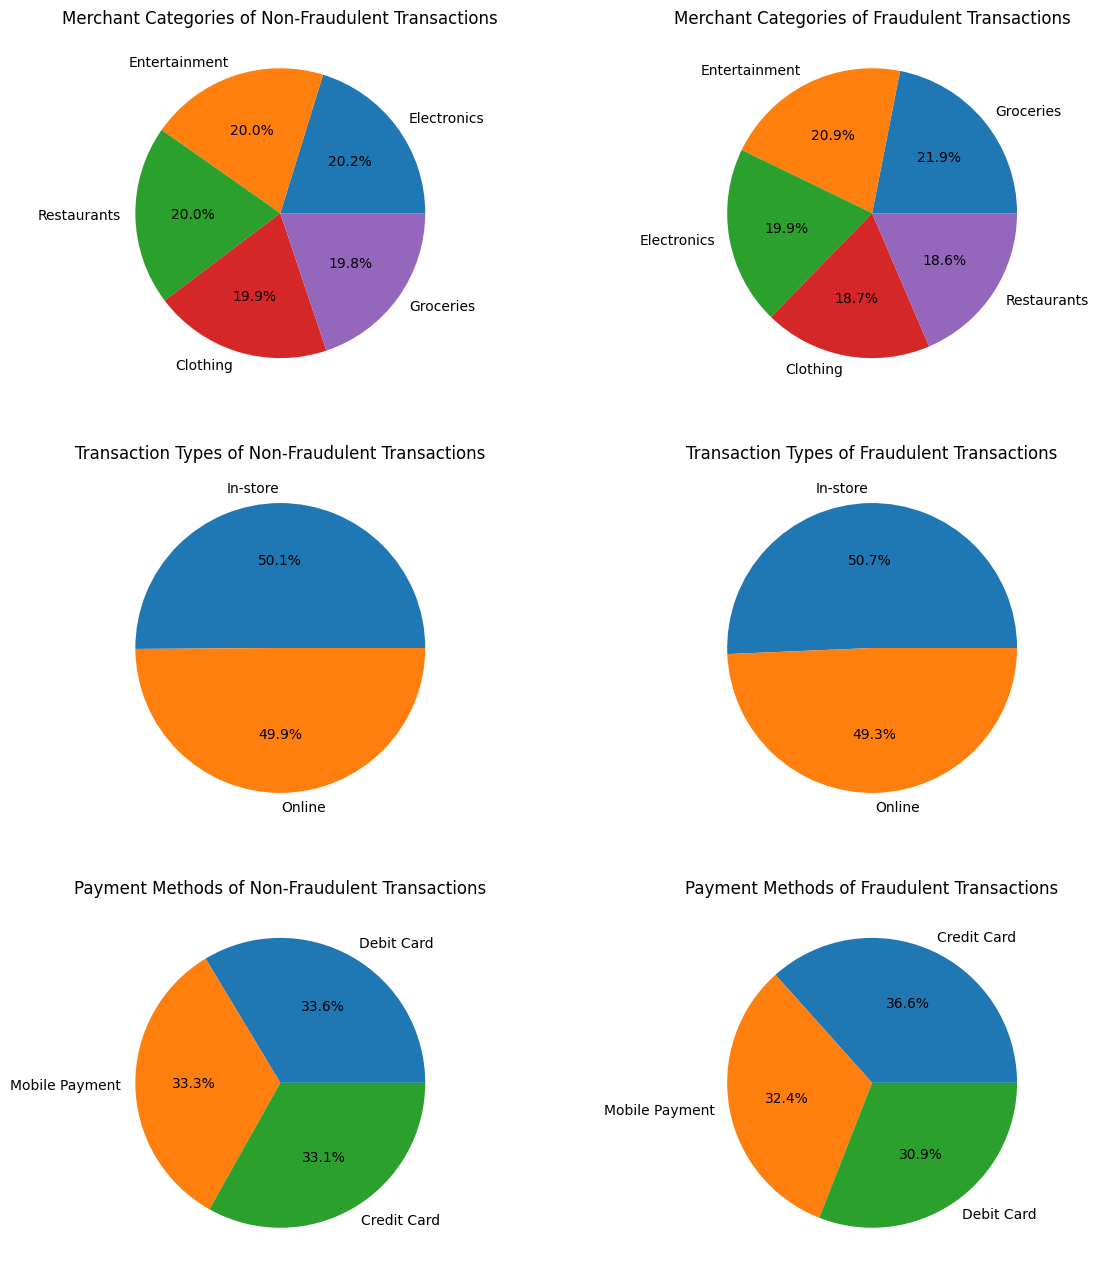

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(14,16))
axes = axes.flatten()

# https://www.geeksforgeeks.org/python/get-unique-values-from-a-column-in-pandas-dataframe/
# https://matplotlib.org/3.1.0/gallery/pie_and_polar_charts/pie_features.html
# https://www.w3schools.com/python/matplotlib_pie_charts.asp
axes[0].pie(df_not_fraud['Merchant_Category'].value_counts(), labels = df_not_fraud['Merchant_Category'].unique(), autopct='%1.1f%%')
axes[0].set_title("Merchant Categories of Non-Fraudulent Transactions")

axes[1].pie(df_fraud['Merchant_Category'].value_counts(), labels = df_fraud['Merchant_Category'].unique(), autopct='%1.1f%%')
axes[1].set_title("Merchant Categories of Fraudulent Transactions")

axes[2].pie(df_not_fraud['Transaction_Type'].value_counts(), labels = df_not_fraud['Transaction_Type'].unique(), autopct='%1.1f%%')
axes[2].set_title("Transaction Types of Non-Fraudulent Transactions")

axes[3].pie(df_fraud['Transaction_Type'].value_counts(), labels = df_fraud['Transaction_Type'].unique(), autopct='%1.1f%%')
axes[3].set_title("Transaction Types of Fraudulent Transactions")

axes[4].pie(df_not_fraud['Payment_Method'].value_counts(), labels = df_not_fraud['Payment_Method'].unique(), autopct='%1.1f%%')
axes[4].set_title("Payment Methods of Non-Fraudulent Transactions")

axes[5].pie(df_fraud['Payment_Method'].value_counts(), labels = df_fraud['Payment_Method'].unique(), autopct='%1.1f%%')
axes[5].set_title("Payment Methods of Fraudulent Transactions")

It looks like the category values among all three categories are overall quite balanced, making it hard by eyeshot to determine if a certain value in any of them is a major hint. It implies that getting more manual review on the transactions may not be the most beneficial if the method of review is to pick off transactions by notable shared traits in the past.

It seems, however, that for fraud transactions, more seem to have a **transaction type** of **Credit Card** than other posible values in that category.

What about more numerical categories like scores and loyalty points earned?

Text(0.5, 1.0, 'Customer Age for Fraudulent Transactions')

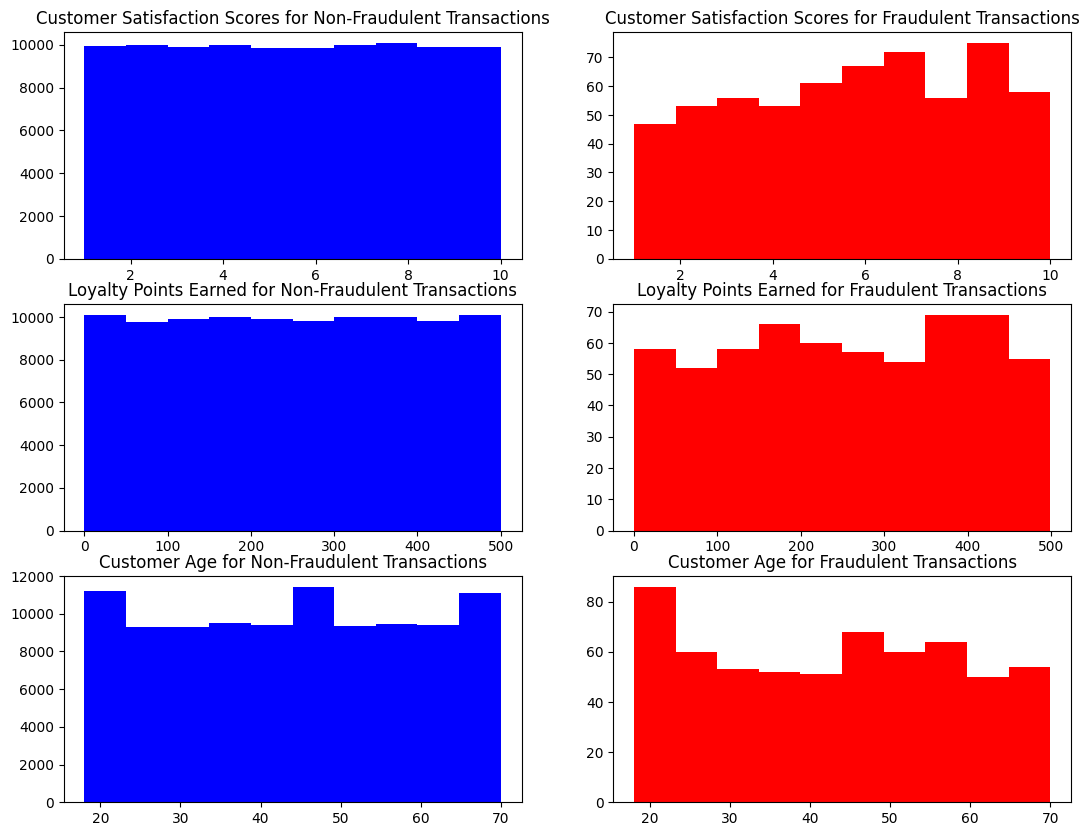

In [161]:
fig, axes = plt.subplots(3, 2, figsize=(13,10))
axes = axes.flatten()

# https://www.geeksforgeeks.org/python/get-unique-values-from-a-column-in-pandas-dataframe/
# https://matplotlib.org/3.1.0/gallery/pie_and_polar_charts/pie_features.html
# https://www.w3schools.com/python/matplotlib_pie_charts.asp
axes[0].hist(df_not_fraud['Customer_Satisfaction_Score'], color ='blue')
axes[0].set_title("Customer Satisfaction Scores for Non-Fraudulent Transactions")

axes[1].hist(df_fraud['Customer_Satisfaction_Score'], color ='red')
axes[1].set_title("Customer Satisfaction Scores for Fraudulent Transactions")

axes[2].hist(df_not_fraud['Loyalty_Points_Earned'], color ='blue')
axes[2].set_title("Loyalty Points Earned for Non-Fraudulent Transactions")

axes[3].hist(df_fraud['Loyalty_Points_Earned'], color ='red')
axes[3].set_title("Loyalty Points Earned for Fraudulent Transactions")

axes[4].hist(df_not_fraud['Customer_Age'], color ='blue')
axes[4].set_title("Customer Age for Non-Fraudulent Transactions")

axes[5].hist(df_fraud['Customer_Age'], color ='red')
axes[5].set_title("Customer Age for Fraudulent Transactions")

These look quite balanced as well across both fraud and non-fraud. It can be inferred that none of these categories are particularly strong indicators of fraud, except for customer age. It appears that a higher amount of people around 20 years old were put through fraudulent transactions. Meanwhile people around 20, closer to 50 than 40, and closer to 70 than 60 were more likely to be involved in non-fraudulent transactions.

#### OPTION B: Detect fraud using simple transaction rules such as transaction amount or location?

#### Let's try getting a boxplot of transaction amounts, as suggested in Option B

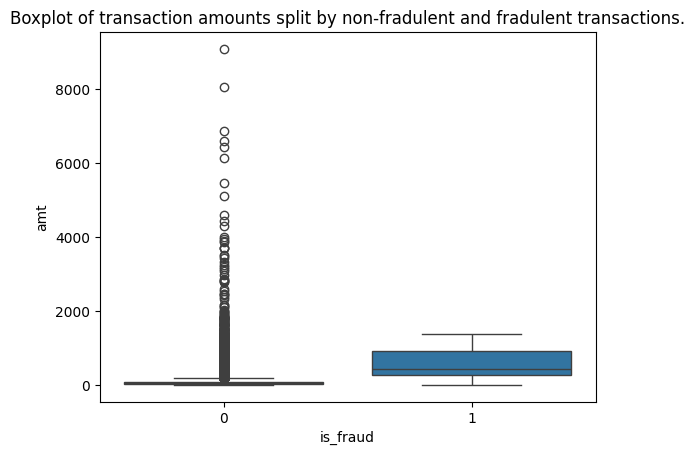

In [17]:
sns.boxplot(x='is_fraud', y='amt', data=df).set(title='Boxplot of transaction amounts split by non-fradulent and fradulent transactions.')
plt.show()

That's a pretty stark difference; there are many outliers in the not-fraud category, but generally speaking the overall monetary amount of non-fraudulent transactions is significantly llower than those of the fraudent type. Granted, the dataset is imbalanced in the sense that many of the transactions in the dataset are not fraudulent. 

Still, given how overwhelmingly different the amount of transactions that are fraud or not, we definitely have to note how no fraudulent transactions go above $2000 in our dataset, but those transactions would tend to be much higher in monetary amount than the average non-fraudulent transaction.

**Therefore, we could guess it it is more likely that that a transaction is below that amount range would be fraud; perhaps, smaller sums of money are favoured in fraudulent transactions so not as to draw attention from fraud detectors. Option B may have some merit when using amount.**

Could we double down on confirming the correlation between amt and fraud? Maybe we can try a **correlation matrix.** We can include other numerical features that we have already discussed, to verify that they do not have much correlation with a transaction being fraud or not.

In [18]:
numeric_features = [
'Customer_Age', 'amt', 'Customer_Satisfaction_Score', 'Loyalty_Points_Earned', 'is_fraud'
]

In [19]:
df_not_fraud["Merchant_Category"].value_counts()

Merchant_Category
Electronics      20106
Entertainment    19918
Groceries        19913
Restaurants      19735
Clothing         19730
Name: count, dtype: int64

In [20]:
fraud_merchant_category_counts = df_fraud["Merchant_Category"].value_counts()

Simple transaction rules could be gleaned from averages, perhaps.

**Could customer age correlate with higher chance of fraud (as people get older, are they more likely to fall into fraud)?**

**Perhaps higher money spent correlates to being involved in fraud?**

https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/

Spearman correlation can work well with ordinal variables such as the amt, Customer_Satisfaction_Score, etc., so we'll stick with that.

In [21]:
spearman_corr_matrix = df[numeric_features].corr(method='spearman')
print(spearman_corr_matrix.round(2))

                             Customer_Age   amt  Customer_Satisfaction_Score  \
Customer_Age                          1.0  0.00                         0.00   
amt                                   0.0  1.00                        -0.00   
Customer_Satisfaction_Score           0.0 -0.00                         1.00   
Loyalty_Points_Earned                -0.0 -0.00                        -0.00   
is_fraud                             -0.0  0.09                         0.01   

                             Loyalty_Points_Earned  is_fraud  
Customer_Age                                  -0.0     -0.00  
amt                                           -0.0      0.09  
Customer_Satisfaction_Score                   -0.0      0.01  
Loyalty_Points_Earned                          1.0      0.00  
is_fraud                                       0.0      1.00  


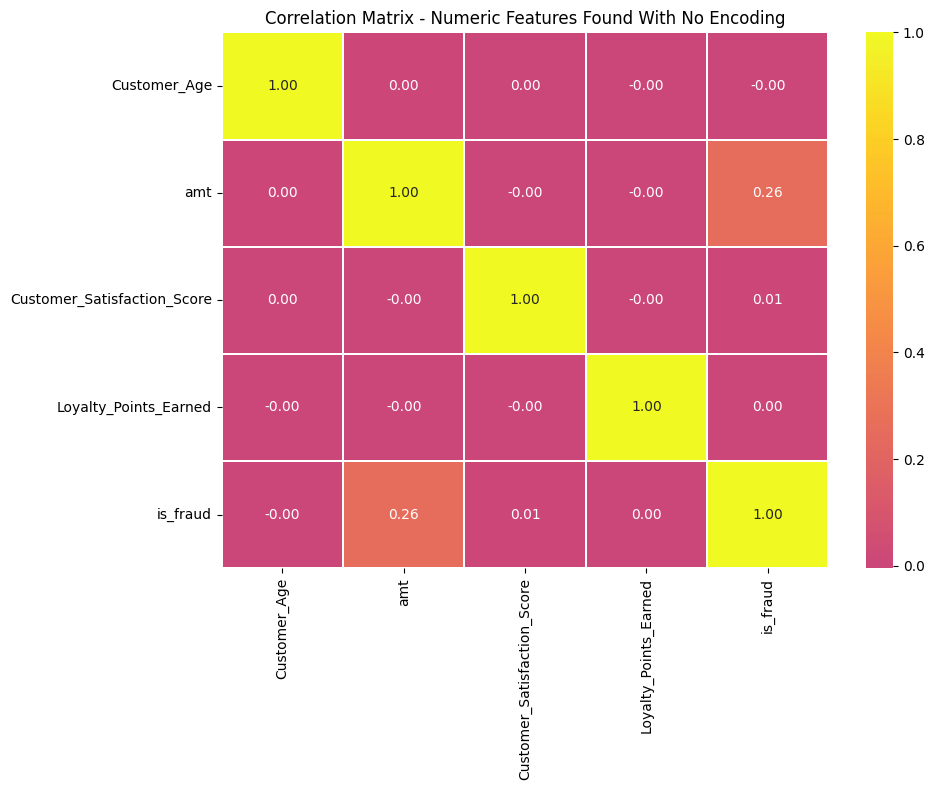

In [22]:
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize = (10, 8))

sns.heatmap (
    corr, 
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center = 0,
    ax = ax,
    linewidths=0.35
)

ax.set_title("Correlation Matrix - Numeric Features Found With No Encoding")
plt.tight_layout()
plt.show()


We can see that the only naturally numerical category that could potentially have a correlation with fraudulent transactions is amt; the amount of a transaction. This lines up with the earlier conclusion drawn from the boxplots, but the correlation isn't strong enough for me to say that this alone warrants fraud declaration; **I would like more evidence for other notable correlations to add onto this observation.**

What about for correlation for non-ordinal categories? Let's keep is_fraud and amt since they are notable, but we are not using Spearman because a lot of these variables aren't ordinal.

Referenced: https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/
https://www.questionpro.com/blog/correlation-matrix/

In [155]:
merchant_dummies = pd.get_dummies(df['Merchant_Category'], prefix='merchant', drop_first=False).astype(int)
transaction_dummies = pd.get_dummies(df['Transaction_Type'], prefix='transaction', drop_first=False).astype(int)
payment_dummies = pd.get_dummies(df['Payment_Method'], prefix='payment', drop_first=False).astype(int)
X = pd.concat([
    df['is_fraud'],
    df['amt'],
    merchant_dummies,
    transaction_dummies,
    payment_dummies
], axis=1)

# Adapted from Assignment 2
assert X.isnull().sum().sum() == 0
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"\nFeature columns \n{X.columns.tolist()}")
X.head(3)


Feature matrix shape: (84824, 12)
Missing values in X: 0

Feature columns 
['is_fraud', 'amt', 'merchant_Clothing', 'merchant_Electronics', 'merchant_Entertainment', 'merchant_Groceries', 'merchant_Restaurants', 'transaction_In-store', 'transaction_Online', 'payment_Credit Card', 'payment_Debit Card', 'payment_Mobile Payment']


,is_fraud,amt,merchant_Clothing,merchant_Electronics,merchant_Entertainment,merchant_Groceries,merchant_Restaurants,transaction_In-store,transaction_Online,payment_Credit Card,payment_Debit Card,payment_Mobile Payment
Unnamed: 0,,,,,,,,,,,,
1045211,0,194.51,0,1,0,0,0,1,0,0,1,0
110142,0,6.53,0,0,0,0,1,0,1,0,1,0
271705,0,64.29,1,0,0,0,0,1,0,0,0,1


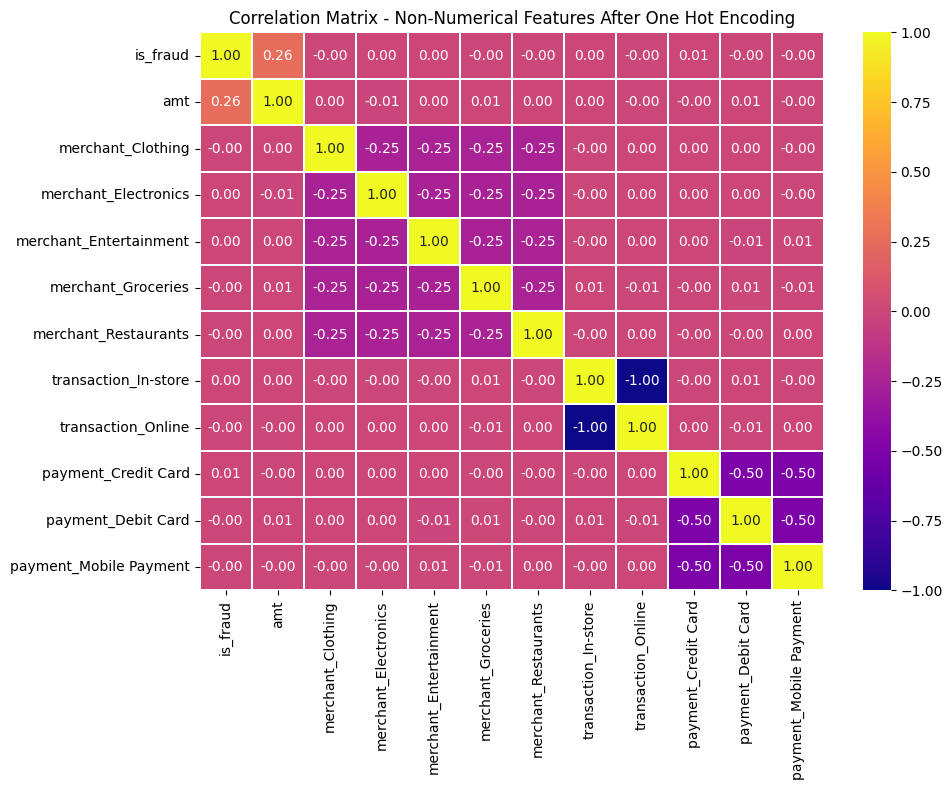

In [164]:
corr = X.corr()

fig, ax = plt.subplots(figsize = (10, 8))

sns.heatmap (
    corr, 
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center = 0,
    ax = ax,
    linewidths=0.35
)

ax.set_title("Correlation Matrix - Non-Numerical Features After One Hot Encoding")
plt.tight_layout()
plt.show()

Hmmm, it appears that with the confusion matrix we can see that there is no notable correlation between any of the categorical types we feature engineered with one hot encoding. Credit Card is the only non-amt variable that has a positive correlation with is_fraud bigger than 0, but it is only a value of 0.01.

How about transaction time? Does that mean anything in particular?

We've got trans_date in one column, can we **feature engineer** columns that isolate them?

We can look for peaks in fraud during certain months, days of the week, and times of the day.

Let's try this on the split not-fraud/fraud datasets.

To hone in on simpler time categories, **let's use a binary variable to represent if transactions took place, that checks if a transaction took place before or after noon**, because halving the day seems like a fair split.

Extracting time values from fraudulent transactions

In [92]:
# Adapted from: https://stackoverflow.com/a/45019364

# Date of transaction (YYYY-MM-DD)
df_fraud['trans_date'] = (np.where(df_fraud['trans_date_trans_time'].str.contains(' '),
                  df_fraud['trans_date_trans_time'].str.split(' ').str[0],
                  df_fraud['trans_date_trans_time']))

# Time of Transaction (HH:MM:SS)
df_fraud['trans_time'] = (np.where(df_fraud['trans_date_trans_time'].str.contains(' '),
                  df_fraud['trans_date_trans_time'].str.split(' ').str[1],
                  df_fraud['trans_date_trans_time']))

# Hour of Transaction (HH)
df_fraud['trans_time_hour'] = (np.where(df_fraud['trans_time'].str.contains(':'),
                  df_fraud['trans_time'].str.split(':').str[0],
                  df_fraud['trans_time']))

# https://stackoverflow.com/a/71977721
df_fraud['trans_time_hour'] = df_fraud['trans_time_hour'].astype('int64')

In [93]:
df_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,is_past_noon_transaction,trans_day_of_week
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
307415,2019-05-29 03:20:26,213124978348176,fraud_Murray Ltd,grocery_net,15.95,Steven,Arnold,M,079 Chelsea Rest,Belfast,NY,14711,42.3200,-78.0943,1766,Mechanical engineer,1962-06-04,2883e6322a7c90c1e8f1c0a90f100b57,1338261626,41.411920,-78.747801,1,15853.0,Groceries,In-store,2,14:09,46,Credit Card,435,2019-05-29,03:20:26,3,0,NaT
1049132,2020-03-10 19:42:02,3546674063249004,"fraud_Zboncak, Rowe and Murazik",shopping_net,1047.60,Jordan,May,M,1626 Susan Course,Aledo,TX,76008,32.7004,-97.6039,13602,Optometrist,1984-07-05,00874b4dca737745c1aa717fddab7d2a,1362944522,32.153247,-98.271148,1,76401.0,Entertainment,In-store,3,10:27,49,Mobile Payment,384,2020-03-10,19:42:02,19,1,NaT
778318,2019-11-29 23:01:08,4736845434667908128,"fraud_Schmeler, Bashirian and Price",shopping_net,828.37,Toni,Gomez,F,062 Carl Dam,Altona,NY,12910,44.8816,-73.6408,2148,"Surveyor, land/geomatics",1953-05-23,7b8a3547a8360a62d0ea2cfa9d9e1398,1354230068,45.734625,-74.157311,1,NaN,Electronics,Online,7,06:24,19,Credit Card,480,2019-11-29,23:01:08,23,1,NaT
1248615,2020-06-03 22:43:46,4538566639857,fraud_Kerluke-Abshire,shopping_net,1091.97,Jerry,Kelly,M,3539 Mckenzie Stream,Fairview,NJ,7022,40.8170,-74.0000,13835,"Programmer, multimedia",1967-05-28,4bc0da420e788a236fec555c610d2368,1370299426,41.466234,-74.132459,1,12575.0,Clothing,Online,3,10:25,28,Credit Card,0,2020-06-03,22:43:46,22,1,NaT
922221,2019-12-31 02:54:26,213155997615567,fraud_Miller-Hauck,grocery_pos,293.09,James,Yoder,M,83359 Lopez Point,Clune,PA,15727,40.5503,-79.3237,168,Race relations officer,1978-10-04,89c143b1c4c01a44634edb6abeea0a7b,1356922466,39.878164,-79.352258,1,15551.0,Clothing,Online,1,21:29,38,Debit Card,458,2019-12-31,02:54:26,2,0,NaT


Extracting time values from non-fraudulent transactions (Already done)

In [94]:
# Adapted from: https://stackoverflow.com/a/45019364
df_not_fraud['trans_date'] = (np.where(df_not_fraud['trans_date_trans_time'].str.contains(' '),
                  df_not_fraud['trans_date_trans_time'].str.split(' ').str[0],
                  df_not_fraud['trans_date_trans_time']))

df_not_fraud['trans_time'] = (np.where(df_not_fraud['trans_date_trans_time'].str.contains(' '),
                  df_not_fraud['trans_date_trans_time'].str.split(' ').str[1],
                  df_not_fraud['trans_date_trans_time']))

df_not_fraud['trans_time_hour'] = (np.where(df_not_fraud['trans_time'].str.contains(':'),
                  df_not_fraud['trans_time'].str.split(':').str[0],
                  df_not_fraud['trans_time']))

# https://stackoverflow.com/a/71977721
df_not_fraud['trans_time_hour'] = df_not_fraud['trans_time_hour'].astype('int64')

In [95]:
df_not_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,trans_day_of_week,is_past_noon_transaction
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332,2020-03-09,15:09:26,15,Monday,1
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476,2019-08-22,15:49:01,15,Thursday,1
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100,2019-03-04,01:34:16,1,Monday,0
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460,2020-06-16,20:04:38,20,Tuesday,1
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372,2019-05-14,05:54:48,5,Tuesday,0


In [111]:
# https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
df_days_of_week_fraud = df_fraud

df_days_of_week_not_fraud = df_not_fraud

In [127]:
df_month_of_year_fraud = df_fraud

df_month_of_year_not_fraud = df_not_fraud

Define a function to convert all values to days. The value-day pairing is based off of DatetimeIndex's own way of calculating the day of the week through dayofweek

In [112]:
def day_of_week(x):
    # As above, based on: https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.dayofweek.html
    if x == 0:
        return 'Monday'
    elif x == 1:
        return 'Tuesday'
    elif x == 2:
        return 'Wednesday'
    elif x == 3:
        return 'Thursday'
    elif x == 4:
        return 'Friday'
    elif x == 5:
        return 'Saturday'
    elif x == 6:
        return 'Sunday'

In [129]:
# Based on https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.month.html
def month_of_year(x):
    if x == 1:
        return 'January'
    elif x == 2:
        return 'February'
    elif x == 3:
        return 'March'
    elif x == 4:
        return 'April'
    elif x == 5:
        return 'May'
    elif x == 6:
        return 'June'
    elif x == 7:
        return 'July'
    elif x == 8:
        return 'August'
    elif x == 9:
        return 'September'
    elif x == 10:
        return 'October'
    elif x == 11:
        return 'November'
    elif x == 12:
        return 'December'

Now, convert the date to a day of the week.

In [113]:
# Convert string format of trans_date to DateTime format for use with DateTime functions
df_days_of_week_fraud['trans_day_of_week'] = pd.to_datetime(df_days_of_week_fraud['trans_date'])
# Now that this is in DateTime, convert to day of week via integer using dayofweek
df_days_of_week_fraud['trans_day_of_week'] = df_days_of_week_fraud['trans_day_of_week'].dt.dayofweek

In [114]:
# Converts integers from dayofweek to proper strings for display in Pie Chart
df_days_of_week_fraud['trans_day_of_week'] = df_days_of_week_fraud['trans_day_of_week'].apply(day_of_week)

In [115]:
df_days_of_week_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,is_past_noon_transaction,trans_day_of_week
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
307415,2019-05-29 03:20:26,213124978348176,fraud_Murray Ltd,grocery_net,15.95,Steven,Arnold,M,079 Chelsea Rest,Belfast,NY,14711,42.3200,-78.0943,1766,Mechanical engineer,1962-06-04,2883e6322a7c90c1e8f1c0a90f100b57,1338261626,41.411920,-78.747801,1,15853.0,Groceries,In-store,2,14:09,46,Credit Card,435,2019-05-29,03:20:26,3,0,Wednesday
1049132,2020-03-10 19:42:02,3546674063249004,"fraud_Zboncak, Rowe and Murazik",shopping_net,1047.60,Jordan,May,M,1626 Susan Course,Aledo,TX,76008,32.7004,-97.6039,13602,Optometrist,1984-07-05,00874b4dca737745c1aa717fddab7d2a,1362944522,32.153247,-98.271148,1,76401.0,Entertainment,In-store,3,10:27,49,Mobile Payment,384,2020-03-10,19:42:02,19,1,Tuesday
778318,2019-11-29 23:01:08,4736845434667908128,"fraud_Schmeler, Bashirian and Price",shopping_net,828.37,Toni,Gomez,F,062 Carl Dam,Altona,NY,12910,44.8816,-73.6408,2148,"Surveyor, land/geomatics",1953-05-23,7b8a3547a8360a62d0ea2cfa9d9e1398,1354230068,45.734625,-74.157311,1,NaN,Electronics,Online,7,06:24,19,Credit Card,480,2019-11-29,23:01:08,23,1,Friday
1248615,2020-06-03 22:43:46,4538566639857,fraud_Kerluke-Abshire,shopping_net,1091.97,Jerry,Kelly,M,3539 Mckenzie Stream,Fairview,NJ,7022,40.8170,-74.0000,13835,"Programmer, multimedia",1967-05-28,4bc0da420e788a236fec555c610d2368,1370299426,41.466234,-74.132459,1,12575.0,Clothing,Online,3,10:25,28,Credit Card,0,2020-06-03,22:43:46,22,1,Wednesday
922221,2019-12-31 02:54:26,213155997615567,fraud_Miller-Hauck,grocery_pos,293.09,James,Yoder,M,83359 Lopez Point,Clune,PA,15727,40.5503,-79.3237,168,Race relations officer,1978-10-04,89c143b1c4c01a44634edb6abeea0a7b,1356922466,39.878164,-79.352258,1,15551.0,Clothing,Online,1,21:29,38,Debit Card,458,2019-12-31,02:54:26,2,0,Tuesday


In [116]:
# Convert dates into integers representing the days of the week based on https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.dayofweek.html
df_days_of_week_not_fraud['trans_day_of_week'] = pd.to_datetime(df_days_of_week_not_fraud['trans_date'])

df_days_of_week_not_fraud['trans_day_of_week'] = df_days_of_week_not_fraud['trans_day_of_week'].dt.dayofweek

In [118]:
df_days_of_week_not_fraud['trans_day_of_week'] = df_days_of_week_not_fraud['trans_day_of_week'].apply(day_of_week) 

In [119]:
df_days_of_week_not_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,trans_day_of_week,is_past_noon_transaction
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332,2020-03-09,15:09:26,15,Monday,1
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476,2019-08-22,15:49:01,15,Thursday,1
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100,2019-03-04,01:34:16,1,Monday,0
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460,2020-06-16,20:04:38,20,Tuesday,1
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372,2019-05-14,05:54:48,5,Tuesday,0


In [120]:
df_not_fraud['trans_day_of_week'] = df_days_of_week_not_fraud['trans_day_of_week']
df_fraud['trans_day_of_week'] = df_days_of_week_fraud['trans_day_of_week']

In [121]:
df_not_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,trans_day_of_week,is_past_noon_transaction
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332,2020-03-09,15:09:26,15,Monday,1
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476,2019-08-22,15:49:01,15,Thursday,1
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100,2019-03-04,01:34:16,1,Monday,0
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460,2020-06-16,20:04:38,20,Tuesday,1
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372,2019-05-14,05:54:48,5,Tuesday,0


Let's do the same for the month of the year.

In [128]:
# Convert dates into integers representing the days of the week based on https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.dayofweek.html
df_month_of_year_not_fraud['trans_month_of_year'] = pd.to_datetime(df_days_of_week_not_fraud['trans_date'])

df_month_of_year_not_fraud['trans_month_of_year'] = df_days_of_week_not_fraud['trans_month_of_year'].dt.month

In [130]:
df_month_of_year_not_fraud['trans_month_of_year'] = df_month_of_year_not_fraud['trans_month_of_year'].apply(month_of_year) 

In [132]:
# Convert dates into integers representing the days of the week based on https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.dayofweek.html
df_month_of_year_fraud['trans_month_of_year'] = pd.to_datetime(df_month_of_year_fraud['trans_date'])

df_month_of_year_fraud['trans_month_of_year'] = df_month_of_year_fraud['trans_month_of_year'].dt.month

In [133]:
df_month_of_year_fraud['trans_month_of_year'] = df_month_of_year_fraud['trans_month_of_year'].apply(month_of_year) 

In [134]:
df_not_fraud['trans_month_of_year'] = df_month_of_year_not_fraud['trans_month_of_year']
df_fraud['trans_month_of_year'] = df_month_of_year_fraud['trans_month_of_year']

In [135]:
df_not_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,trans_day_of_week,is_past_noon_transaction,trans_month_of_year
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332,2020-03-09,15:09:26,15,Monday,1,March
547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476,2019-08-22,15:49:01,15,Thursday,1,August
110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100,2019-03-04,01:34:16,1,Monday,0,March
1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460,2020-06-16,20:04:38,20,Tuesday,1,June
271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372,2019-05-14,05:54:48,5,Tuesday,0,May


In [136]:
df_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned,trans_date,trans_time,trans_time_hour,is_past_noon_transaction,trans_day_of_week,trans_month_of_year
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
307415,2019-05-29 03:20:26,213124978348176,fraud_Murray Ltd,grocery_net,15.95,Steven,Arnold,M,079 Chelsea Rest,Belfast,NY,14711,42.3200,-78.0943,1766,Mechanical engineer,1962-06-04,2883e6322a7c90c1e8f1c0a90f100b57,1338261626,41.411920,-78.747801,1,15853.0,Groceries,In-store,2,14:09,46,Credit Card,435,2019-05-29,03:20:26,3,0,Wednesday,May
1049132,2020-03-10 19:42:02,3546674063249004,"fraud_Zboncak, Rowe and Murazik",shopping_net,1047.60,Jordan,May,M,1626 Susan Course,Aledo,TX,76008,32.7004,-97.6039,13602,Optometrist,1984-07-05,00874b4dca737745c1aa717fddab7d2a,1362944522,32.153247,-98.271148,1,76401.0,Entertainment,In-store,3,10:27,49,Mobile Payment,384,2020-03-10,19:42:02,19,1,Tuesday,March
778318,2019-11-29 23:01:08,4736845434667908128,"fraud_Schmeler, Bashirian and Price",shopping_net,828.37,Toni,Gomez,F,062 Carl Dam,Altona,NY,12910,44.8816,-73.6408,2148,"Surveyor, land/geomatics",1953-05-23,7b8a3547a8360a62d0ea2cfa9d9e1398,1354230068,45.734625,-74.157311,1,NaN,Electronics,Online,7,06:24,19,Credit Card,480,2019-11-29,23:01:08,23,1,Friday,November
1248615,2020-06-03 22:43:46,4538566639857,fraud_Kerluke-Abshire,shopping_net,1091.97,Jerry,Kelly,M,3539 Mckenzie Stream,Fairview,NJ,7022,40.8170,-74.0000,13835,"Programmer, multimedia",1967-05-28,4bc0da420e788a236fec555c610d2368,1370299426,41.466234,-74.132459,1,12575.0,Clothing,Online,3,10:25,28,Credit Card,0,2020-06-03,22:43:46,22,1,Wednesday,June
922221,2019-12-31 02:54:26,213155997615567,fraud_Miller-Hauck,grocery_pos,293.09,James,Yoder,M,83359 Lopez Point,Clune,PA,15727,40.5503,-79.3237,168,Race relations officer,1978-10-04,89c143b1c4c01a44634edb6abeea0a7b,1356922466,39.878164,-79.352258,1,15551.0,Clothing,Online,1,21:29,38,Debit Card,458,2019-12-31,02:54:26,2,0,Tuesday,December


Text(0.5, 1.0, 'Fraud During Months of Year')

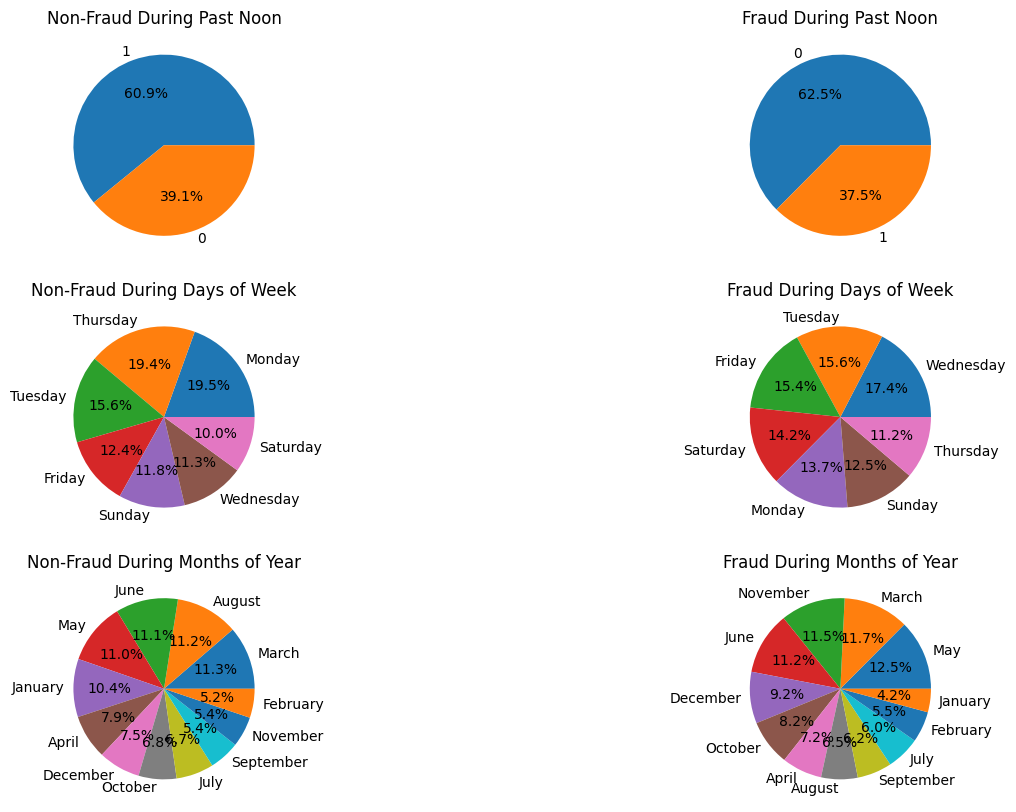

In [165]:
# Adapted from Week 5 code.

# # extract features from timestamp
# df["is_weekend"] = (df["transaction_at"].dt.dayofweek >= 5).astype(int)
df_fraud["is_past_noon_transaction"] = (
    (df_fraud["trans_time_hour"] >= 12) &
    (df_fraud["trans_time_hour"] <= 24)
).astype(int)

df_not_fraud["is_past_noon_transaction"] = (
    (df_not_fraud["trans_time_hour"] >= 12) &
    (df_not_fraud["trans_time_hour"] <= 24)
).astype(int)

day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

axes[0].pie(df_not_fraud["is_past_noon_transaction"].value_counts(), labels=df_not_fraud["is_past_noon_transaction"].unique(), autopct='%1.1f%%')
axes[0].set_title("Non-Fraud During Past Noon")

axes[1].pie(df_fraud["is_past_noon_transaction"].value_counts(), labels=df_fraud["is_past_noon_transaction"].unique(), autopct='%1.1f%%')
axes[1].set_title("Fraud During Past Noon")

axes[2].pie(df_not_fraud['trans_day_of_week'].value_counts(), labels=df_not_fraud['trans_day_of_week'].unique(), autopct='%1.1f%%')
axes[2].set_title("Non-Fraud During Days of Week")

axes[3].pie(df_fraud["trans_day_of_week"].value_counts(), labels=df_fraud["trans_day_of_week"].unique(), autopct='%1.1f%%')
axes[3].set_title("Fraud During Days of Week")

axes[4].pie(df_not_fraud['trans_month_of_year'].value_counts(), labels=df_not_fraud['trans_month_of_year'].unique(), autopct='%1.1f%%')
axes[4].set_title("Non-Fraud During Months of Year")

axes[5].pie(df_fraud['trans_month_of_year'].value_counts(), labels=df_fraud['trans_month_of_year'].unique(), autopct='%1.1f%%')
axes[5].set_title("Fraud During Months of Year")

Interesting, the amount of fraudulent transactions happening before noon is almost double the amount happening after noon. Conversely, the amount of non-fradulent transactions happing past noon is almost double the amount happening before noon.

In terms of days of the week, there is an overally fairly balanced spread for both non-fraud and fraud, even though Thursday and Monday appears to take a little lead in terms of non-fraud.

The balance is mostly there for months of the year as well; the highest amount of non-fraud AND fraud happens during June, May nd March. But notable are the months of November an August. **Fraud appears to happen in November 11.5% of the time versus non-fraud happening 5.4% of the time during that month.** Meanwhile, **non-fraud happens 11.2% of the time in August compared to non-fraud happening 6.5% of the time in August**, so special attention could be taken for those months when determining if a transaction is more likely to be fraud or not based on month. Of course, we have to consider the fact that the datasets are imbalanced but these differences are notable enough in my opinion to be stated.

**This suggests that while it is harder to distinguish fraudulent transactions based on the day they occured, it is still observable that fraudulent transactions are more likely to happen before noon, and fraud is more likely to happen during November.**

#### To conclude, it is difficult to pick just option A or B, because across both fraud and non-fraud transactions, transactions do not have one specific variable that is a decidedly telltale sign of fraud.

#### Instead, there are multiple little factors that can be checked that can collectively add up to allow for more accurate identification of fraud.

### I would therefore say that OPTION C - to use an AI model keeping track of multiple aspects of transactions - IS IDEAL.

Yet, a mix of all three options in tandem could be employed: AI models (option C) can be fed rules that specifically look out for these key details (for instance, if the transaction's amount is at or below $2000) (option B), and combined, note these aspects to label a transaction as fraudulent, which a manual checker (option A) can then look into for further inspection using other details - perhaps ones outside the scope of the included dataset like a customer's transaction history.

#### This leads, then, to the question of Phase 2: What aspects of fraud are important to note and what type of machine learning model would be iedal for a situation like this?

From the provided dataset, notable variables are:

**- Customer_Age: Ages around 20 appeared to be involved in more fraudulent transactions than other age groups.**

**- amt: Fraudulent transactions have been shown to be under $2000 while non-fraudulent transactions span a much wider range of numbers.**

**- trans_date_trans_time: Fradulent transactions tend to happen before noon. Fraud is most likely to happen in November versus non-fraud. Non-fraud is most likely to happen in August versus fraud.**

A notable variables that weren't covered in this EDA that should also be looked into is Latitude and Longitude; lat, long, merch_lat and merch_long. Having a visual representation of the location spread between fraudulent and non-fraudulent transactions would be nice to identify instances where the same person have been the victim of multiple frauds, and businesses which have been involved in one or more fraudulent cases of fraud.

I think the answer, being a **classification problem**, would have to fall upon a **supervised learning model**; something that uses a dataset like this, actually, that has labels denoting whether something is fraud or not, so that the model can begin learning by establish connections between multiple known fraudulent transactions in a vacuum, and know how to place lesser weight on noted transaction details that are less likely to be problematic. As more types of transactions are identified, the model can make a greater sense of patterns than even this EDA managed to find, using a method like Logistic Regression which is ideal classification. I would however, note that the dataset used for training and testing absolutely needs a much more balanced split between fraud and non-fraud than the one the EDA in this notebook was performed in; the model would need much more information on fraudulent transactions so it can determine patterns more reliably.

On the topic of reliability, the evalauaton metrics that are important would consist of the **F1-score**, as it provides an overall general view of the model's general success rate, **accuracy**, as I believe it is of utmost importance is it ability to guess BOTH fraudulent and non-fraudulent transactions correctly, and **precision**, because it useful to track the model's aversion to false positives due to incorrectly flagging a non-fraudulent transaction as fraudulent, which could cause manual reviewers to use up time reviewing transactions that are actually alright when they could be spending time on reviewing actually fraudulent transactions.

References for writeup:
    
https://www.geeksforgeeks.org/machine-learning/types-of-machine-learning/

https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/

https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall 

# Link to presentation: https://drive.google.com/drive/folders/1mzKqbfoIu8ifDlMHnGlIbcm26cJJZAXi?usp=sharing 